# 基于 Spark 的 B 站"每周必看"视频数据分析

**班级**：23 数据科学与大数据技术
**学号**：XXXXXXXXXX
**姓名**：XXX

---


## 一、实验环境

| 项目 | 说明 |
|------|------|
| 操作系统 | Windows 10/11 / Linux |
| JDK 版本 | JDK 17+ |
| Spark 版本 | 4.1.2 |
| Python 版本 | 3.11+ |
| 开发工具 | PyCharm / Jupyter Notebook |
| 可视化库 | matplotlib、seaborn |
| 机器学习 | Spark MLlib (pyspark.ml) |
| 文本挖掘 | jieba、TF-IDF |


## 二、数据集介绍

### 2.1 数据来源与背景

B 站（bilibili）是国内知名的视频分享平台，其"每周必看"栏目每周精选优质视频推荐给用户体验。本数据集通过 B 站官方 API 爬取了从 2019 年第 1 期至 2026 年第 22 期共 **377 期**的"每周必看"数据，涵盖约 **14000 条**视频记录。

### 2.2 数据格式

数据以 JSON 格式存储，每个文件对应一期"每周必看"，文件命名为 `week_001.json` ~ `week_377.json`。

### 2.3 主要字段说明

| 字段 | 类型 | 说明 |
|------|------|------|
| number | int | 期数编号 |
| config.subject | string | 本期主题 |
| config.name | string | 期数名称（含日期范围） |
| config.stime / etime | long | 起止时间戳 |
| aid | long | 视频 AV 号 |
| bvid | string | 视频 BV 号 |
| title | string | 视频标题 |
| tid / tname | int / string | 分区 ID / 分区名称 |
| pubdate | long | 投稿时间戳 |
| duration | int | 视频时长（秒） |
| desc | string | 视频简介 |
| rcmd_reason | string | 推荐理由 |
| owner.mid / owner.name | long / string | UP 主 ID / 昵称 |
| stat.view | long | 播放量 |
| stat.danmaku | long | 弹幕数 |
| stat.reply | long | 评论数 |
| stat.favorite | long | 收藏数 |
| stat.coin | long | 投币数 |
| stat.share | long | 分享数 |
| stat.like | long | 点赞数 |


## 三、数据预处理

### 3.1 初始化 Spark 环境

本项目使用 Spark 4.1.2 **Spark Connect** 模式。Spark Connect 是 Spark 3.4+ 引入的客户端-服务器架构，客户端通过 gRPC 与 Spark Server 通信，无需在本地嵌入 JVM。客户端体积从 ~400MB 降至 ~1.5MB。

> **Spark 4.0+ 重大改进**：从 Spark 4.0 开始，标准 `pyspark.ml` API（包括 `KMeans`、`LinearRegression`、`VectorAssembler` 等）**全面支持 Spark Connect**，不再需要 `pyspark.ml.connect` 子集的替代方案。本项目在 5.9-5.11 节直接使用原生 MLlib API。

**启动 Spark Connect Server**（在运行 notebook 前，需在终端执行）：

```bash
# Linux / macOS
$SPARK_HOME/sbin/start-connect-server.sh

# Windows（手动启动）
spark-class org.apache.spark.sql.connect.SparkConnectServer
```

Server 默认监听 `sc://localhost:15002`。


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window
import sys, os, warnings
warnings.filterwarnings('ignore')

# ============================================================
# Spark Connect 模式 SparkSession
# - 通过 sc:// 协议连接到独立运行的 Spark Connect Server
# - Server 端负责创建 SparkContext 和调度任务
# - 客户端只做 DataFrame 构建 / 结果收集, 资源占用低
# - 启动 Server: ./sbin/start-connect-server.sh --master local[*]
# - 默认端口 15002
# - Spark 4.0+: pyspark.ml 全系列 API 原生支持 Spark Connect
#   (VectorAssembler / KMeans / LinearRegression / ClusteringEvaluator 等)
# - 数据从本地 HDFS 读 (hdfs://localhost:9000/...) 需保证 Hadoop 已配好
# ============================================================
SPARK_CONNECT_URL = 'sc://192.168.121.134:15002'

# === Python 版本对齐 (driver 3.11 vs worker) ===
# mapInPandas 等操作要求 worker 进程的 Python 与 driver 一致.
# 如果 Server 端 Python 版本不同, 需在启动 Connect Server 时设置:
#   export PYSPARK_PYTHON=/usr/bin/python3.11
#   ./sbin/start-connect-server.sh --master local[*]
PYTHON_BIN = sys.executable if os.name == 'nt' else 'python3.11'

spark = (SparkSession.builder
    .remote(SPARK_CONNECT_URL)
    .appName('Bilibili Weekly Picks Analysis')
    .config('spark.sql.shuffle.partitions', '4')
    .config('spark.sql.adaptive.enabled', 'true')
    .config('spark.sql.execution.arrow.pyspark.enabled', 'true')
    .config('spark.pyspark.python', PYTHON_BIN)
    .config('spark.pyspark.driver.python', PYTHON_BIN)
    .getOrCreate())

print(f'Spark 版本: {spark.version}')
print(f'连接模式: Spark Connect ({SPARK_CONNECT_URL})')
print(f'Worker Python: {PYTHON_BIN}')
print('SparkSession 创建成功！')


Spark 版本: 4.1.2
连接模式: Spark Connect (sc://192.168.121.134:15002)
Worker Python: D:\Desktop\BiliAnalysis\.venv\Scripts\python.exe
SparkSession 创建成功！


### 3.2 读取 JSON 数据

使用 Spark 的 `spark.read.json()` 批量读取 HDFS 上的 `week_*.json` 文件。


In [2]:
# ============================================================
# 读取所有 JSON 文件
# multiLine=True: 每个文件是完整的多行 JSON 数组, 而非 JSONL
# ============================================================
DATA_PATH = 'hdfs://localhost:9000/user/hadoop/bilibili/raw/week_*.json'

raw_df = spark.read.option('multiLine', 'true').json(DATA_PATH)

print(f'原始数据总行数: {raw_df.count()} 期')


原始数据总行数: 377 期


### 3.3 展开嵌套结构

JSON 数据中 `videos` 字段是一个数组，需要用 `explode` 展开为多行，再提取各个子字段。


In [3]:
# ============================================================
# Step 1: explode videos 数组 -> 每个视频一行
# Step 2: 提取嵌套字段, 拍平为 DataFrame 列
# ============================================================

exploded_df = raw_df.select(
    F.col('number').alias('week_number'),          # 期数
    F.col('config.name').alias('week_name'),        # 期数名称
    F.col('config.subject').alias('week_subject'),  # 本期主题
    F.col('config.stime').alias('week_start'),      # 起始时间戳
    F.explode('videos').alias('video')              # 展开视频数组
)

videos_df = exploded_df.select(
    'week_number', 'week_name', 'week_subject',
    # --- 视频基本信息 ---
    F.col('video.aid').alias('aid'),
    F.col('video.bvid').alias('bvid'),
    F.col('video.title').alias('title'),
    F.col('video.tid').alias('tid'),
    F.col('video.tname').alias('category'),                  # 分区名称
    F.col('video.pid_name_v2').alias('sub_category'),        # 二级分区
    F.col('video.pubdate').alias('pubdate'),                 # 投稿时间戳
    F.col('video.duration').alias('duration'),               # 时长 (秒)
    F.col('video.desc').alias('description'),                # 简介
    F.col('video.rcmd_reason').alias('rcmd_reason'),         # 推荐理由
    # --- UP 主信息 ---
    F.col('video.owner.mid').alias('creator_mid'),
    F.col('video.owner.name').alias('creator_name'),
    # --- 互动数据 ---
    F.col('video.stat.view').alias('view'),
    F.col('video.stat.danmaku').alias('danmaku'),
    F.col('video.stat.reply').alias('reply'),
    F.col('video.stat.favorite').alias('favorite'),
    F.col('video.stat.coin').alias('coin'),
    F.col('video.stat.share').alias('share'),
    F.col('video.stat.like').alias('like'),
)

total_videos = videos_df.count()
print(f'展开后视频总条数: {total_videos}')
print('前 5 条数据预览:')
display(videos_df.limit(5).toPandas())


展开后视频总条数: 14074
前 5 条数据预览:


,week_number,week_name,week_subject,aid,bvid,title,tid,category,sub_category,pubdate,...,rcmd_reason,creator_mid,creator_name,view,danmaku,reply,favorite,coin,share,like
0,314,2025第314期 03.21 - 03.27,最强葫芦娃鬼畜调教,114201066479129,BV1GPX1YpErE,少看一集都剪不出来,22,鬼畜调教,鬼畜,1742623200,...,这对…对吗？,16054375,自动鬼畜中的WZ,8068486,2991,4376,122104,153678,26710,613616
1,314,2025第314期 03.21 - 03.27,最强葫芦娃鬼畜调教,114203599831927,BV1xXXnYkEDd,内娱“黑社会”驾到，通通闪开！全网闹事，刷新下限【 内娱315事件】,241,娱乐杂谈,娱乐,1742609307,...,这也可以？,20457232,一只吐槽圆,16544277,100991,11528,149712,583401,50148,822311
2,314,2025第314期 03.21 - 03.27,最强葫芦娃鬼畜调教,114204438698173,BV1xfXpYjEJP,曾经连续三年百大，美食区的顶流，如今欠债几百万，这几年我都经历了什么？！,212,美食侦探,知识,1742623233,...,这也太难防了,2920960,大祥哥来了,8422950,45784,33627,107037,531433,173182,526941
3,314,2025第314期 03.21 - 03.27,最强葫芦娃鬼畜调教,114200898705115,BV1aHXkYVEHC,小羊村,138,搞笑,小剧场,1742569248,...,小游戏大合集,5970160,小潮院长,16401190,47522,11121,230496,225516,13805,672375
4,314,2025第314期 03.21 - 03.27,最强葫芦娃鬼畜调教,114199288093320,BV1daXrY2EPt,求求你，别再刀了！B站陈奕迅《跳楼机》真.粤语版,31,翻唱,音乐,1742560200,...,好听！,1712395,不是词神,15717142,5834,20468,381936,471354,200188,628803


### 3.4 时间字段转换

将 `pubdate` 时间戳转为可读的日期字段，并计算视频时长（分钟）。


In [4]:
# ============================================================
# 时间戳 -> 日期字段
# duration: 秒 -> 分钟, 保留 1 位小数
# ============================================================
videos_df = (videos_df
    .withColumn('pub_date', F.from_unixtime('pubdate', 'yyyy-MM-dd'))
    .withColumn('pub_year', F.year(F.from_unixtime('pubdate')))
    .withColumn('pub_month', F.month(F.from_unixtime('pubdate')))
    .withColumn('duration_min', F.round(F.col('duration') / 60.0, 1))
)

print('时间字段转换完成, 新增字段: pub_date, pub_year, pub_month, duration_min')
display(videos_df.select('title', 'pub_date', 'pub_year', 'duration_min').limit(5).toPandas())


时间字段转换完成, 新增字段: pub_date, pub_year, pub_month, duration_min


,title,pub_date,pub_year,duration_min
0,少看一集都剪不出来,2025-03-22,2025,2.1
1,内娱“黑社会”驾到，通通闪开！全网闹事，刷新下限【 内娱315事件】,2025-03-22,2025,13.1
2,曾经连续三年百大，美食区的顶流，如今欠债几百万，这几年我都经历了什么？！,2025-03-22,2025,16.8
3,小羊村,2025-03-21,2025,38.3
4,求求你，别再刀了！B站陈奕迅《跳楼机》真.粤语版,2025-03-21,2025,3.4


### 3.5 数据清洗

检查并处理缺失值、重复数据和异常值。


In [5]:
# ============================================================
# 1. 检查关键字段的空值情况
# 用一次 agg 聚合计算所有字段的空值, 避免循环触发多个 Job
# ============================================================
key_cols = ['aid', 'title', 'category', 'view', 'like', 'creator_name', 'duration']

null_exprs = [F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in key_cols]
null_counts = videos_df.select(null_exprs).collect()[0]

print('=== 关键字段空值统计 ===')
for c in key_cols:
    nc = null_counts[c]
    print(f'  {c:>15s}: {nc} 条空值 ({nc/total_videos*100:.2f}%)')

# ============================================================
# 2. 去除 aid 为空的记录 (无法标识视频)
# ============================================================
clean_df = videos_df.filter(F.col('aid').isNotNull())

# ============================================================
# 3. 去重: 同一个 aid 可能在不同期被重复推荐
#    保留第一次出现的那条 (按 week_number 升序)
# ============================================================
dedup_window = Window.partitionBy('aid').orderBy('week_number')
clean_df = (clean_df
    .withColumn('rn', F.row_number().over(dedup_window))
    .filter(F.col('rn') == 1)
    .drop('rn'))

clean_count = clean_df.count()
print(f'\n清洗后视频总数: {clean_count}')
print(f'去重移除: {total_videos - clean_count} 条')


=== 关键字段空值统计 ===
              aid: 0 条空值 (0.00%)
            title: 0 条空值 (0.00%)
         category: 0 条空值 (0.00%)
             view: 0 条空值 (0.00%)
             like: 0 条空值 (0.00%)
     creator_name: 0 条空值 (0.00%)
         duration: 0 条空值 (0.00%)

清洗后视频总数: 14033
去重移除: 41 条


In [6]:
# ============================================================
# 4. 异常值检测: 播放量为 0 或负数的记录
# ============================================================
abnormal = clean_df.filter(F.col('view') <= 0).count()
print(f'播放量 <= 0 的异常记录: {abnormal} 条')

# 过滤掉播放量为 0 的记录
clean_df = clean_df.filter(F.col('view') > 0)

# ============================================================
# cache(): 将 clean_df 缓存到内存, 后续操作不再重复计算
# 这是性能优化的关键一步!
# ============================================================
clean_df = clean_df.cache()
print(f'最终有效视频数: {clean_df.count()} 条 (已缓存到内存)')

# ============================================================
# 5. 基本统计描述
# ============================================================
print('\n=== 数值字段统计摘要 ===')
display(clean_df.select('view', 'like', 'coin', 'favorite', 'share', 'danmaku', 'reply', 'duration_min') \
    .describe().toPandas())


播放量 <= 0 的异常记录: 0 条
最终有效视频数: 14033 条 (已缓存到内存)

=== 数值字段统计摘要 ===


,summary,view,like,coin,favorite,share,danmaku,reply,duration_min
0,count,14033,14033,14033,14033,14033,14033,14033,14033
1,mean,5675506.559894535,357934.7671916197,151503.9766265232,100133.79712107177,30591.120074111022,23692.431625454286,8722.35088719447,16.343967790208794
2,stddev,5195717.132964547,324797.0661207515,248555.42530158666,145981.8463679015,59373.75029182137,106906.76292971005,66077.08938061008,218.1834873415232
3,min,205830,2588,125,93,66,0,0,0.2
4,max,127422631,6360004,7481737,3743866,2529335,10287168,6901101,25357.6


## 四、数据分析

### 4.1 分区 (Category) 分布分析

统计各分区的视频数量，了解"每周必看"中哪些类型的内容最受欢迎。


In [7]:
# ============================================================
# 按分区分组, 统计视频数量和平均播放量
# ============================================================
category_stats = clean_df.groupBy('category').agg(
    F.count('*').alias('video_count'),                        # 视频数量
    F.round(F.avg('view'), 0).alias('avg_view'),             # 平均播放量
    F.round(F.avg('like'), 0).alias('avg_like'),             # 平均点赞数
    F.sum('view').alias('total_view'),                       # 总播放量
).orderBy(F.desc('video_count'))

print('=== Top 15 分区 (按视频数量排序) ===')
display(category_stats.limit(15).toPandas())


=== Top 15 分区 (按视频数量排序) ===


,category,video_count,avg_view,avg_like,total_view
0,搞笑,1314,8323193.0,497046.0,10936675574
1,单机游戏,905,6427752.0,363772.0,5817115446
2,日常,806,5359275.0,402020.0,4319575538
3,手机游戏,740,5309309.0,283870.0,3928888712
4,同人·手书,576,5422723.0,402897.0,3123488377
5,影视杂谈,486,4164829.0,209856.0,2024107060
6,美食制作,451,6149476.0,403862.0,2773413456
7,人文历史,418,5853485.0,307947.0,2446756930
8,科学科普,416,5479623.0,340488.0,2279523230
9,出行,386,4665424.0,262793.0,1800853706


### 4.2 播放量 Top 20 视频

找出播放量最高的视频，分析爆款视频的特征。


In [8]:
top_videos = clean_df.select(
    'title', 'category', 'creator_name', 'pub_date',
    'view', 'like', 'coin', 'favorite', 'share', 'duration_min'
).orderBy(F.desc('view')).limit(20)

print('=== 播放量 Top 20 视频 ===')
display(top_videos.toPandas())


=== 播放量 Top 20 视频 ===


,title,category,creator_name,pub_date,view,like,coin,favorite,share,duration_min
0,敢 杀 我 的 马？！,鬼畜调教,哦呼w,2020-07-11,127422631,5373318,4564918,2663323,695208,2.4
1,【派大星的独白】一个关于正常人的故事,鬼畜调教,洛温阿特金森,2019-07-27,94147983,5721897,5807096,3551698,1209143,3.7
2,【哔哩哔哩2020拜年祭】,综合,哔哩哔哩拜年纪,2020-01-24,76402692,2958150,3009417,1984954,387286,215.6
3,最 强 法 海,鬼畜调教,推背兔の,2020-05-18,67927563,2520348,1439861,1238848,458237,1.7
4,曾火遍全网的《溯》，你是否还知道？,MAD·AMV,三栗lili,2020-01-26,66172422,3106184,2372370,2312798,239188,3.2
5,游戏科学新作《黑神话：悟空》13分钟实机演示,单机游戏,黑神话,2020-08-20,64871216,3531922,3685345,1322089,1536796,13.0
6,“每日一遍，智商再见”,综合,枫泽雨畔,2020-03-15,63434171,3060755,1811590,1493626,507713,3.3
7,凤凰传奇翻唱《海底》,音乐现场,浙江卫视,2021-04-24,62639660,2276671,873326,1431441,420351,4.1
8,回村三天，二舅治好了我的精神内耗,日常,衣戈猜想,2022-07-25,58006052,6360004,7481737,2636028,2529335,11.5
9,【现 代 圣 杯 战 争】,搞笑,野纯Cz,2019-12-27,57571193,2439646,1616593,1258681,492551,2.6


### 4.3 UP 主排行榜分析

统计各 UP 主的上榜次数和总播放量。


In [9]:
# ============================================================
# 按 UP 主聚合: 上榜次数、总播放量、平均播放量
# ============================================================
creator_rank = clean_df.groupBy('creator_mid', 'creator_name').agg(
    F.count('*').alias('appear_count'),          # 上榜次数
    F.sum('view').alias('total_view'),           # 累计播放量
    F.round(F.avg('view'), 0).alias('avg_view'), # 平均播放量
    F.sum('like').alias('total_like'),           # 累计点赞
).orderBy(F.desc('appear_count'))

print('=== 上榜次数 Top 15 UP 主 ===')
display(creator_rank.limit(15).toPandas())

print('\n=== 累计播放量 Top 15 UP 主 ===')
display(creator_rank.orderBy(F.desc('total_view')).limit(15).toPandas())


=== 上榜次数 Top 15 UP 主 ===


,creator_mid,creator_name,appear_count,total_view,avg_view,total_like
0,546195,老番茄,169,1515540769,8967697.0,100839606
1,5970160,小潮院长,155,2976646405,19204170.0,116550835
2,99157282,盗月社食遇记,130,599412136,4610863.0,41970436
3,23947287,小约翰可汗,129,1015462843,7871805.0,42231397
4,401742377,原神,125,826706736,6613654.0,49595196
5,14110780,凉风Kaze,117,503098602,4299988.0,45114635
6,63231,泛式,109,461263260,4231773.0,32114776
7,946974,影视飓风,105,625312646,5955359.0,39206274
8,18202105,绵羊料理,98,766230432,7818678.0,49764473
9,517327498,罗翔说刑法,85,417274939,4909117.0,33623283



=== 累计播放量 Top 15 UP 主 ===


,creator_mid,creator_name,appear_count,total_view,avg_view,total_like
0,5970160,小潮院长,155,2976646405,19204170.0,116550835
1,546195,老番茄,169,1515540769,8967697.0,100839606
2,23947287,小约翰可汗,129,1015462843,7871805.0,42231397
3,5294454,逗比的雀巢,69,923689369,13386802.0,54732571
4,401742377,原神,125,826706736,6613654.0,49595196
5,18202105,绵羊料理,98,766230432,7818678.0,49764473
6,1340190821,崩坏星穹铁道,79,680321194,8611661.0,36607337
7,946974,影视飓风,105,625312646,5955359.0,39206274
8,99157282,盗月社食遇记,130,599412136,4610863.0,41970436
9,163637592,老师好我叫何同学,50,596235122,11924702.0,48930636


### 4.4 互动指标相关性分析

计算播放量与各互动指标之间的相关系数，分析哪些指标与播放量关系最密切。


In [10]:
# ============================================================
# corr: 计算两个列之间的 Pearson 相关系数
# 相关系数范围 [-1, 1], 越接近 1 表示正相关越强
# ============================================================
metrics = ['like', 'coin', 'favorite', 'share', 'danmaku', 'reply']

print('=== 播放量与各指标的相关系数 ===')
for metric in metrics:
    corr_val = clean_df.stat.corr('view', metric)
    bar = '█' * int(abs(corr_val) * 30)
    print(f'  view vs {metric:>10s}: {corr_val:.4f}  {bar}')

# ============================================================
# 各互动指标之间的相关性矩阵
# 利用对称性只计算上三角, 减少一半计算量
# ============================================================
print('\n=== 互动指标间的相关系数矩阵 ===')
all_metrics = ['view'] + metrics
n = len(all_metrics)

corr_cache = {}
for i in range(n):
    for j in range(i, n):
        corr_cache[(i, j)] = clean_df.stat.corr(all_metrics[i], all_metrics[j])

header = f'{"":>12s}' + ''.join(f'{m:>12s}' for m in all_metrics)
print(header)
for i in range(n):
    row = f'{all_metrics[i]:>12s}'
    for j in range(n):
        if i == j:
            c = 1.0
        elif i < j:
            c = corr_cache[(i, j)]
        else:
            c = corr_cache[(j, i)]
        row += f'{c:>12.4f}'
    print(row)


=== 播放量与各指标的相关系数 ===
  view vs       like: 0.7557  ██████████████████████
  view vs       coin: 0.5749  █████████████████
  view vs   favorite: 0.7124  █████████████████████
  view vs      share: 0.5373  ████████████████
  view vs    danmaku: 0.2582  ███████
  view vs      reply: 0.1267  ███

=== 互动指标间的相关系数矩阵 ===
                    view        like        coin    favorite       share     danmaku       reply
        view      1.0000      0.7557      0.5749      0.7124      0.5373      0.2582      0.1267
        like      0.7557      1.0000      0.7702      0.7106      0.5645      0.1985      0.0866
        coin      0.5749      0.7702      1.0000      0.7021      0.6109      0.2366      0.1142
    favorite      0.7124      0.7106      0.7021      1.0000      0.6075      0.2187      0.1013
       share      0.5373      0.5645      0.6109      0.6075      1.0000      0.2550      0.1953
     danmaku      0.2582      0.1985      0.2366      0.2187      0.2550      1.0000      0.8121
      

### 4.5 视频时长分布与播放量关系

将视频按时长分段，分析不同时长区间的播放表现。


In [11]:
# ============================================================
# when/otherwise: Spark 的条件表达式, 类似 SQL 的 CASE WHEN
# 字符串字典序会让 '10-20 min' 排在 '3-5 min' 之前, 所以加一列数值顺序键
# ============================================================
duration_df = clean_df.withColumn(
    'duration_group',
    F.when(F.col('duration_min') <= 1, '0-1 min')
     .when(F.col('duration_min') <= 3, '1-3 min')
     .when(F.col('duration_min') <= 5, '3-5 min')
     .when(F.col('duration_min') <= 10, '5-10 min')
     .when(F.col('duration_min') <= 20, '10-20 min')
     .when(F.col('duration_min') <= 60, '20-60 min')
     .otherwise('60+ min')
).withColumn(
    'duration_order',
    F.when(F.col('duration_min') <= 1, 1)
     .when(F.col('duration_min') <= 3, 2)
     .when(F.col('duration_min') <= 5, 3)
     .when(F.col('duration_min') <= 10, 4)
     .when(F.col('duration_min') <= 20, 5)
     .when(F.col('duration_min') <= 60, 6)
     .otherwise(7)
)

duration_stats = (duration_df
    .groupBy('duration_group', 'duration_order')
    .agg(
        F.count('*').alias('count'),
        F.round(F.avg('view'), 0).alias('avg_view'),
        F.round(F.avg('like'), 0).alias('avg_like'),
        F.round(F.avg('coin'), 0).alias('avg_coin'),
    )
    .orderBy('duration_order')
    .drop('duration_order'))

print('=== 不同时长区间的视频统计 ===')
display(duration_stats.toPandas())


=== 不同时长区间的视频统计 ===


,duration_group,count,avg_view,avg_like,avg_coin
0,0-1 min,520,5598877.0,486496.0,70260.0
1,1-3 min,3097,5889176.0,418907.0,114747.0
2,3-5 min,2362,5933652.0,377026.0,162848.0
3,5-10 min,3076,5675092.0,362017.0,165663.0
4,10-20 min,2827,5496717.0,317525.0,168789.0
5,20-60 min,1738,5185648.0,266339.0,160879.0
6,60+ min,413,5981710.0,261320.0,201322.0


### 4.6 年度趋势分析

分析不同年份的视频数量、平均播放量变化趋势。


In [12]:
# ============================================================
# 按年份聚合, 观察"每周必看"的内容变化趋势
# ============================================================
yearly_trend = clean_df.groupBy('pub_year').agg(
    F.count('*').alias('video_count'),
    F.round(F.avg('view'), 0).alias('avg_view'),
    F.round(F.avg('like'), 0).alias('avg_like'),
    F.round(F.avg('duration_min'), 1).alias('avg_duration'),
    F.countDistinct('creator_mid').alias('unique_creators'),
).orderBy('pub_year')

print('=== 年度趋势统计 ===')
display(yearly_trend.toPandas())


=== 年度趋势统计 ===


,pub_year,video_count,avg_view,avg_like,avg_duration,unique_creators
0,2019,649,6138579.0,337551.0,10.1,341
1,2020,1334,6483957.0,437367.0,13.2,633
2,2021,1851,6242582.0,418364.0,29.1,827
3,2022,2280,5721906.0,426795.0,11.2,1190
4,2023,2180,5399761.0,362658.0,12.0,1137
5,2024,2224,5166236.0,308212.0,13.8,1123
6,2025,2363,5728872.0,295122.0,18.9,1197
7,2026,1152,4870982.0,259952.0,20.9,706


### 4.7 投币率与收藏率分析

投币率（coin/view）和收藏率（favorite/view）反映了用户对视频质量的认可程度。


In [13]:
# ============================================================
# 计算各分区的平均投币率和收藏率
# ============================================================
engagement_df = (clean_df
    .withColumn('coin_rate', F.col('coin') / F.col('view'))
    .withColumn('fav_rate', F.col('favorite') / F.col('view'))
    .withColumn('like_rate', F.col('like') / F.col('view'))
)

engagement_by_cat = (engagement_df
    .groupBy('category')
    .agg(
        F.count('*').alias('count'),
        F.round(F.avg('coin_rate') * 100, 3).alias('avg_coin_rate_pct'),
        F.round(F.avg('fav_rate') * 100, 3).alias('avg_fav_rate_pct'),
        F.round(F.avg('like_rate') * 100, 3).alias('avg_like_rate_pct'),
    )
    .filter(F.col('count') >= 50)
    .orderBy(F.desc('avg_coin_rate_pct')))

print('=== 各分区互动率排行 (按投币率, 仅展示 >= 50 条视频的分区) ===')
display(engagement_by_cat.limit(15).toPandas())


=== 各分区互动率排行 (按投币率, 仅展示 >= 50 条视频的分区) ===


,category,count,avg_coin_rate_pct,avg_fav_rate_pct,avg_like_rate_pct
0,模玩·周边,52,5.382,2.374,9.412
1,配音,65,4.739,2.105,8.510
2,MAD·AMV,125,4.427,4.114,8.570
3,极客DIY,110,3.925,1.581,7.118
4,同人·手书,576,3.804,2.921,8.561
5,人力VOCALOID,88,3.589,2.569,8.264
6,日常,806,3.558,1.489,7.601
7,综合,264,3.471,2.552,7.910
8,MMD·3D,69,3.436,3.381,9.257
9,电子竞技,350,3.354,1.064,5.829


## 五、数据可视化

使用 matplotlib 和 seaborn 对 Spark 分析结果进行可视化展示。


In [14]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# 中文字体: 必须显式 addfont, 不能只写名字.
# 按名字('SimHei')在 matplotlib 3.7+ 经常找不到, 原因是字体缓存里
# 这几个名字可能被映射成 Noto 系列, 而且 win 系统里 SimHei 的 ttf
# 也叫 '黑体' / 'SimHei' 都有可能. 最稳的办法是直接加载 .ttf 文件.
# ============================================================
_cjk_candidates = [
    r'C:\Windows\Fonts\simhei.ttf',          # Windows 黑体
    r'C:\Windows\Fonts\msyh.ttc',            # 微软雅黑
    r'C:\Windows\Fonts\NotoSansSC-VF.ttf',   # Noto Sans SC (variable)
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',  # Linux 容器
    '/System/Library/Fonts/PingFang.ttc',                      # macOS
]
_cjk_name = None
for _f in _cjk_candidates:
    if Path(_f).exists():
        fm.fontManager.addfont(_f)
        _cjk_name = fm.FontProperties(fname=_f).get_name()
        print(f'已注册中文字体: {_f}  ->  名称: {_cjk_name}')
        break
if _cjk_name is None:
    _cjk_name = 'DejaVu Sans'
    print('警告: 未找到 CJK 字体, 中文可能显示为方块')

# ============================================================
# ⚠ 顺序关键: sns.set_style 必须在 rcParams 字体设置之前调用!
# sns.set_style('whitegrid') 会重置 font.sans-serif 为
# ['Arial', 'DejaVu Sans', ...], 覆盖掉 SimHei, 导致中文变方块.
# 先调 set_style, 再设字体, 才能保证 CJK 字体生效.
# ============================================================
sns.set_style('whitegrid')

plt.rcParams['font.sans-serif'] = [_cjk_name, 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示
plt.rcParams['figure.dpi'] = 120

# ============================================================
# 统一图片保存目录
# ============================================================
FIGURES_DIR = Path('figures/spark/')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'图片保存目录: {FIGURES_DIR.resolve()}')

# 公共配色
PALETTE = sns.color_palette('husl', 12)

已注册中文字体: C:\Windows\Fonts\simhei.ttf  ->  名称: SimHei
图片保存目录: D:\Desktop\BiliAnalysis\figures\spark


### 5.1 分区视频数量分布 (柱状图)


findfont: Failed to find font weight bold, now using 400.


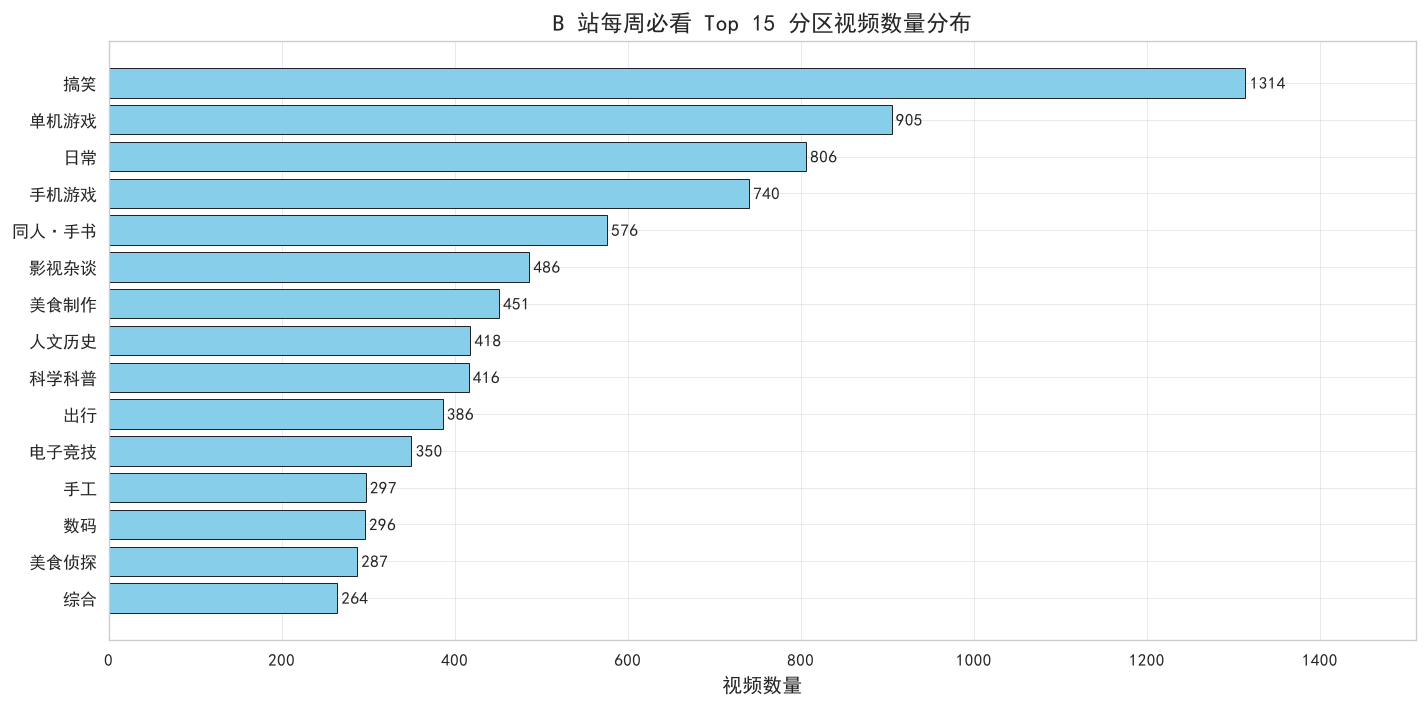

图 1: 分区视频数量分布


In [15]:
# ============================================================
# 将 Spark DataFrame 转为 Pandas 后绘图
# toPandas(): 将分布式数据收集到 Driver 端
# ============================================================
cat_pdf = category_stats.limit(15).toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cat_pdf['category'][::-1], cat_pdf['video_count'][::-1],
               color='skyblue', edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, cat_pdf['video_count'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)

ax.set_xlabel('视频数量', fontsize=12)
ax.set_title('B 站每周必看 Top 15 分区视频数量分布', fontsize=14, fontweight='bold')
ax.set_xlim(0, cat_pdf['video_count'].max() * 1.15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('图 1: 分区视频数量分布')


### 5.2 各分区平均播放量 Top 15 (柱状图)


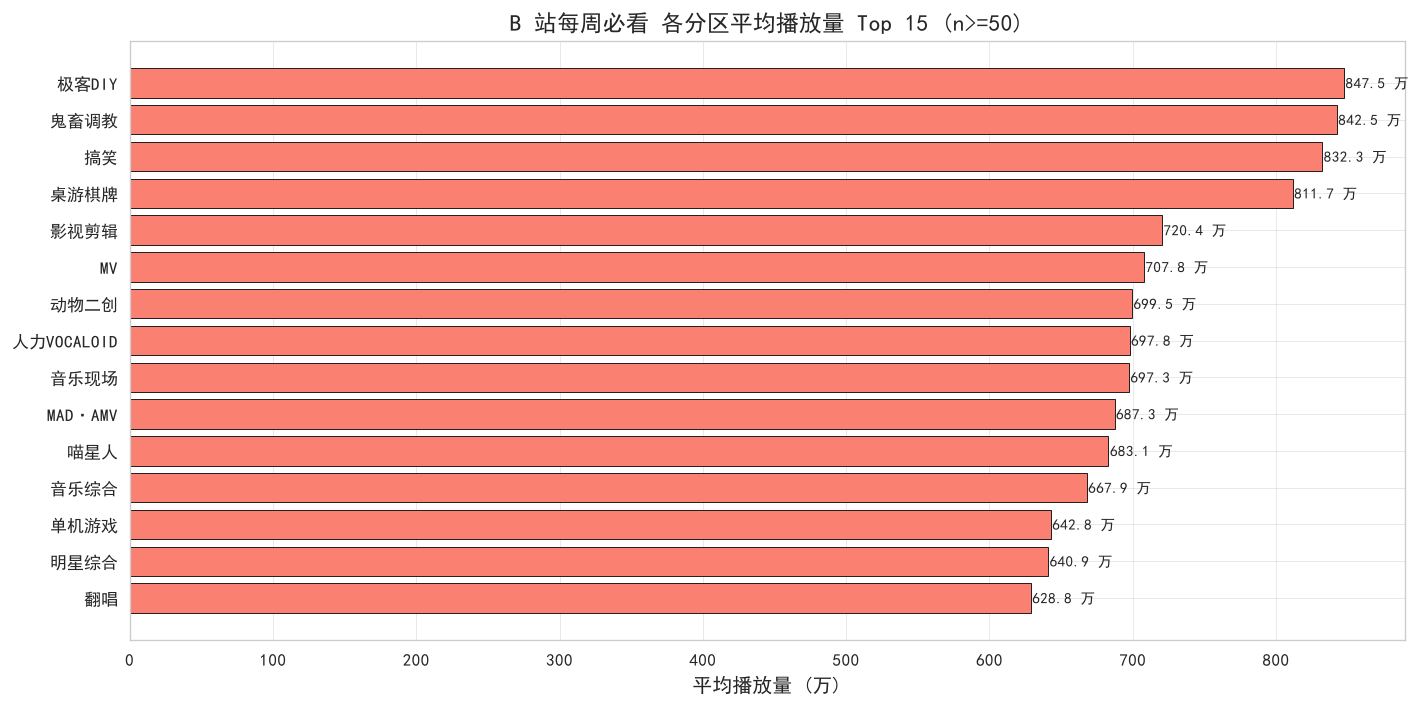

图 2: 各分区平均播放量


In [16]:
cat_view_pdf = (clean_df.groupBy('category')
                .agg(F.round(F.avg('view'), 0).alias('avg_view'),
                     F.count('*').alias('n'))
                .filter(F.col('n') >= 50)
                .orderBy(F.desc('avg_view'))
                .limit(15).toPandas())

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cat_view_pdf['category'][::-1], cat_view_pdf['avg_view'][::-1] / 1e4,
               color='salmon', edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, cat_view_pdf['avg_view'][::-1] / 1e4):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} 万', va='center', fontsize=9)

ax.set_xlabel('平均播放量 (万)', fontsize=12)
ax.set_title('B 站每周必看 各分区平均播放量 Top 15 (n>=50)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_category_avg_view.png', dpi=150, bbox_inches='tight')
plt.show()
print('图 2: 各分区平均播放量')


### 5.3 UP 主上榜次数 Top 15 (柱状图)


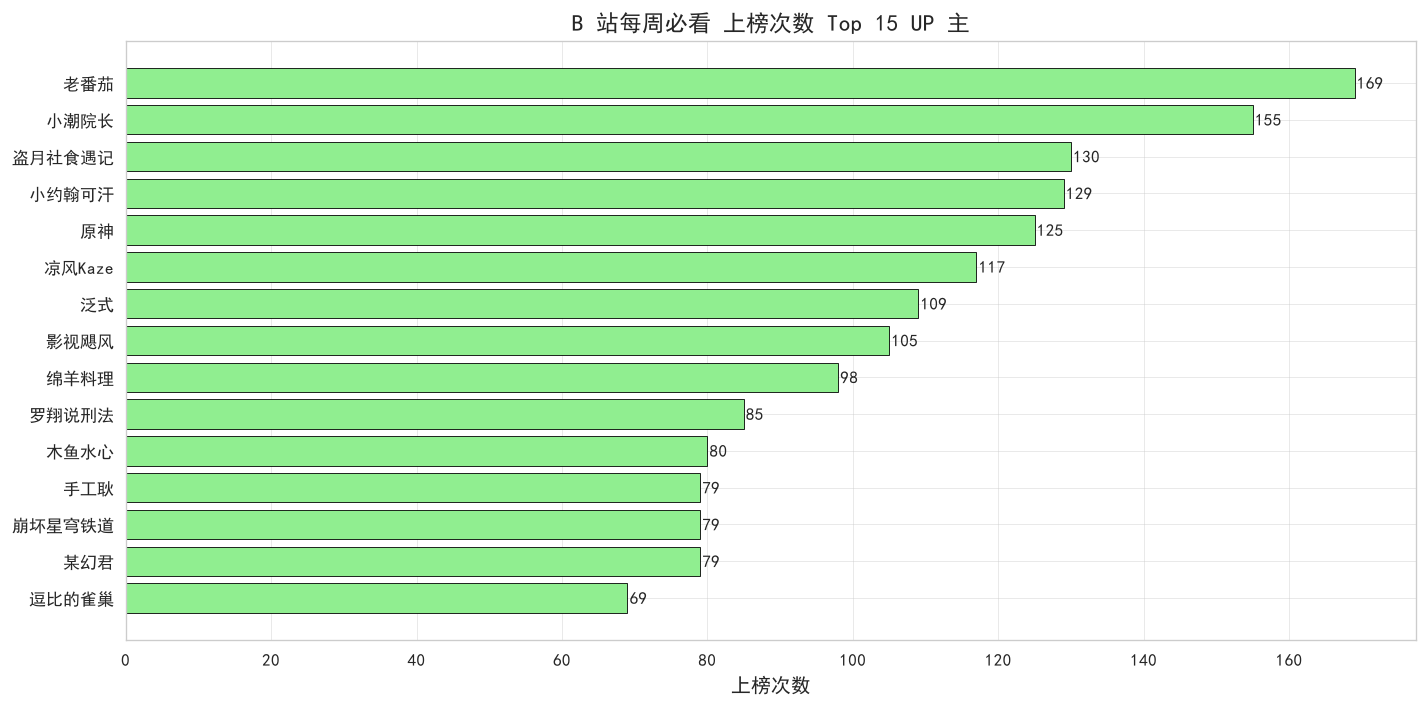

图 3: UP 主上榜次数排行


In [17]:
creator_pdf = creator_rank.limit(15).toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(creator_pdf['creator_name'][::-1], creator_pdf['appear_count'][::-1],
               color='lightgreen', edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, creator_pdf['appear_count'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)

ax.set_xlabel('上榜次数', fontsize=12)
ax.set_title('B 站每周必看 上榜次数 Top 15 UP 主', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_top_creators.png', dpi=150, bbox_inches='tight')
plt.show()
print('图 3: UP 主上榜次数排行')


### 5.4 互动指标相关性热力图


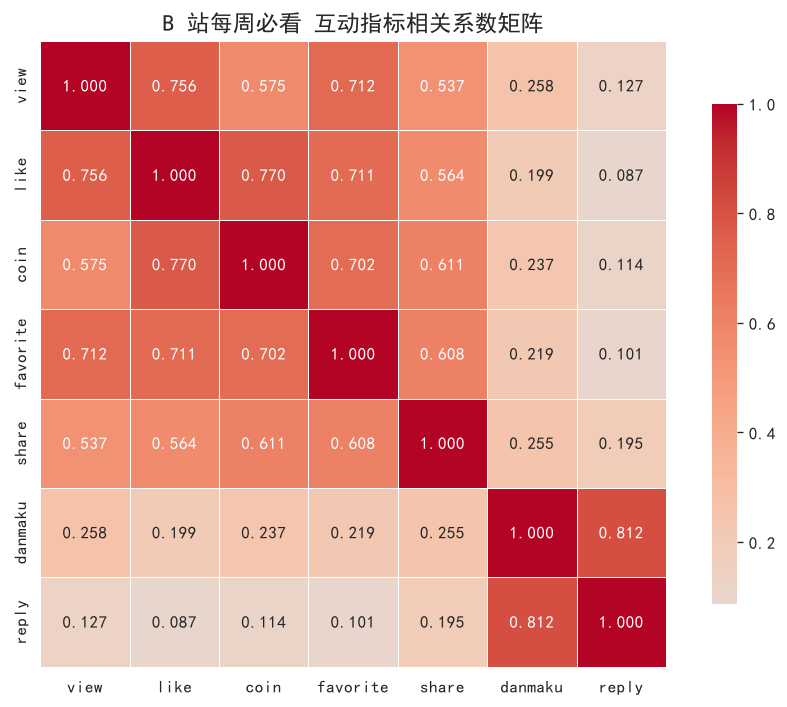

图 4: 互动指标相关性热力图


In [18]:
all_metrics = ['view', 'like', 'coin', 'favorite', 'share', 'danmaku', 'reply']
corr_matrix = pd.DataFrame(index=all_metrics, columns=all_metrics, dtype=float)

for i, m1 in enumerate(all_metrics):
    for j, m2 in enumerate(all_metrics):
        if i == j:
            corr_matrix.loc[m1, m2] = 1.0
        elif i < j:
            corr_matrix.loc[m1, m2] = corr_cache[(i, j)]
        else:
            corr_matrix.loc[m1, m2] = corr_cache[(j, i)]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix.astype(float), annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('B 站每周必看 互动指标相关系数矩阵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('图 4: 互动指标相关性热力图')


### 5.5 视频时长分布


findfont: Failed to find font weight bold, now using 400.


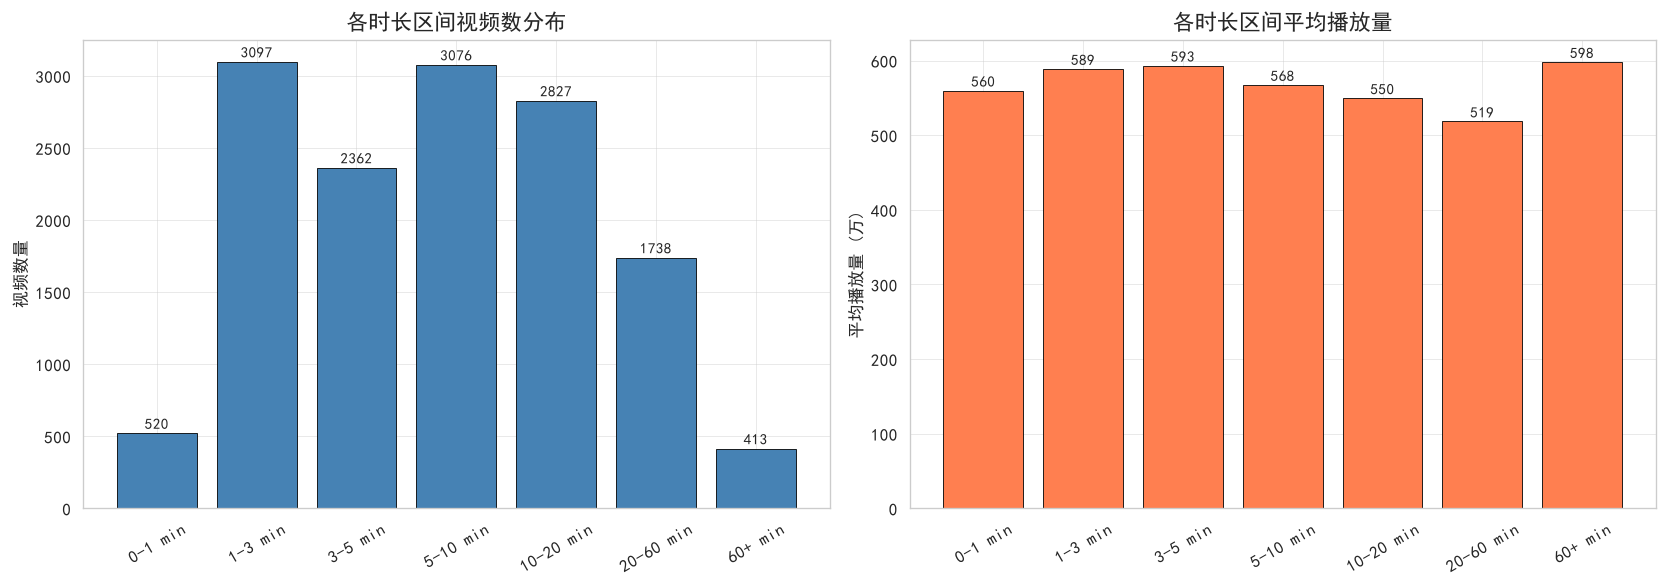

图 5: 视频时长分布


In [19]:
dur_pdf = duration_stats.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 各时长区间视频数
axes[0].bar(dur_pdf['duration_group'], dur_pdf['count'],
            color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_title('各时长区间视频数分布', fontsize=13, fontweight='bold')
axes[0].set_ylabel('视频数量')
axes[0].tick_params(axis='x', rotation=30)
for x, y in zip(dur_pdf['duration_group'], dur_pdf['count']):
    axes[0].text(x, y + 30, str(y), ha='center', fontsize=9)

# 右图: 各时长区间平均播放量
axes[1].bar(dur_pdf['duration_group'], dur_pdf['avg_view'] / 1e4,
            color='coral', edgecolor='black', linewidth=0.5)
axes[1].set_title('各时长区间平均播放量', fontsize=13, fontweight='bold')
axes[1].set_ylabel('平均播放量 (万)')
axes[1].tick_params(axis='x', rotation=30)
for x, y in zip(dur_pdf['duration_group'], dur_pdf['avg_view'] / 1e4):
    axes[1].text(x, y + 5, f'{y:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('图 5: 视频时长分布')


### 5.6 年度趋势 (折线图)


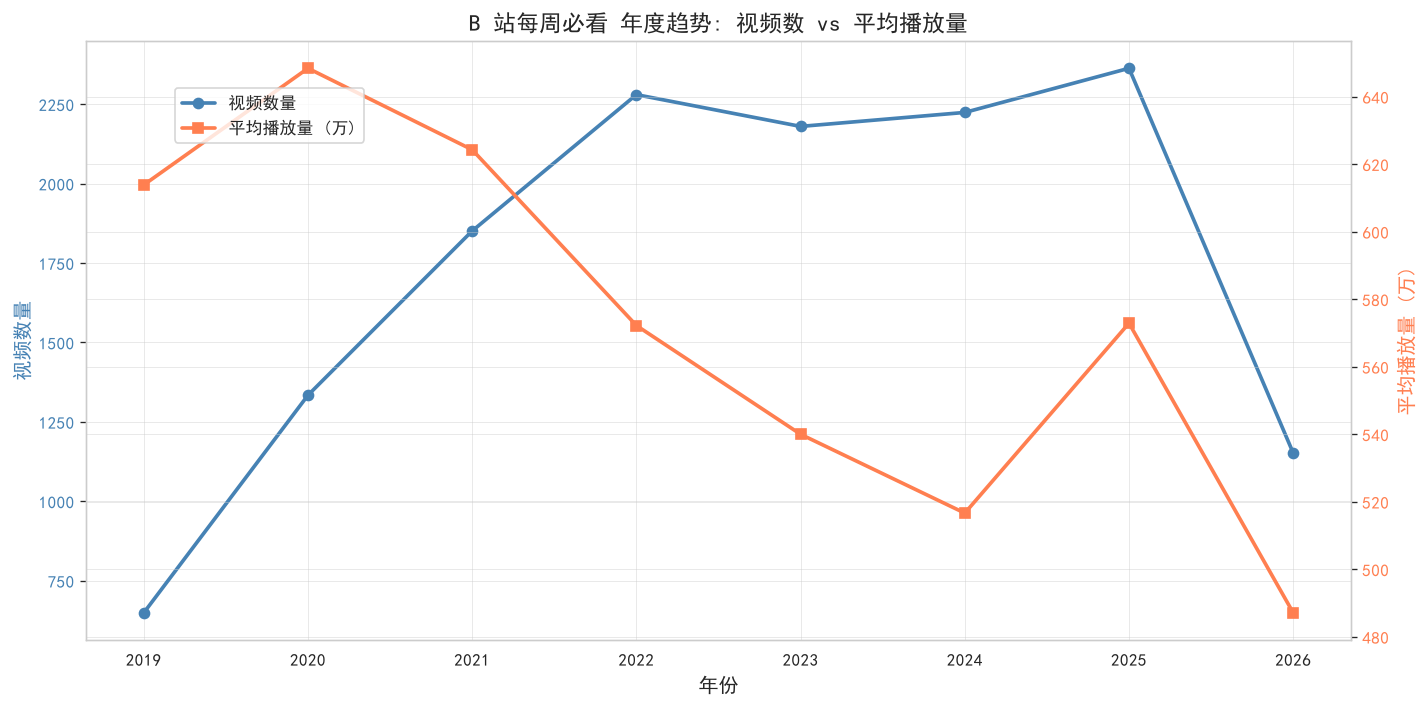

图 6: 年度趋势


In [20]:
year_pdf = yearly_trend.toPandas()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(year_pdf['pub_year'], year_pdf['video_count'],
         marker='o', linewidth=2.2, color='steelblue', label='视频数量')
ax1.set_xlabel('年份', fontsize=12)
ax1.set_ylabel('视频数量', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(year_pdf['pub_year'])

ax2 = ax1.twinx()
ax2.plot(year_pdf['pub_year'], year_pdf['avg_view'] / 1e4,
         marker='s', linewidth=2.2, color='coral', label='平均播放量 (万)')
ax2.set_ylabel('平均播放量 (万)', color='coral', fontsize=12)
ax2.tick_params(axis='y', labelcolor='coral')

plt.title('B 站每周必看 年度趋势: 视频数 vs 平均播放量', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('图 6: 年度趋势')


### 5.7 互动率分区分组柱状图


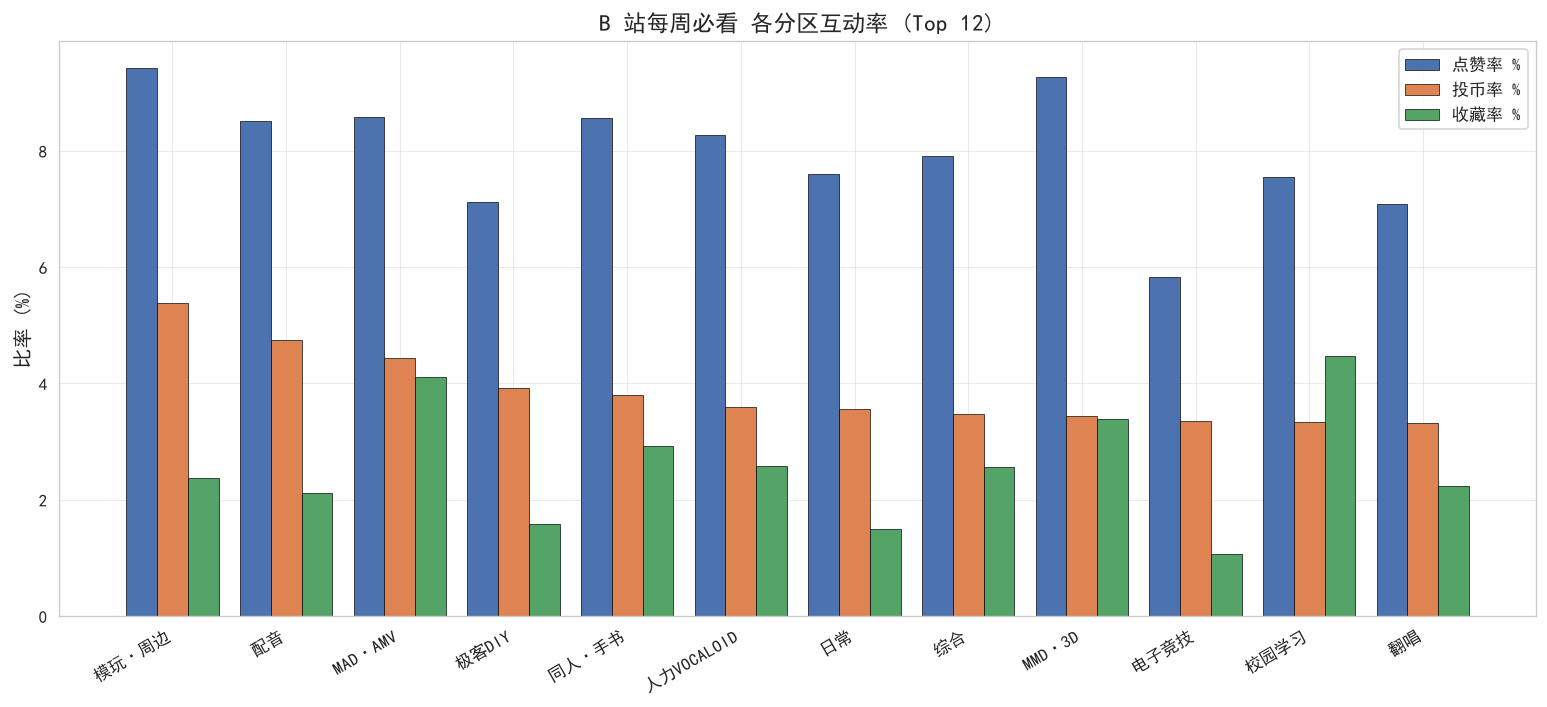

图 7: 各分区互动率


In [21]:
eng_pdf = engagement_by_cat.limit(12).toPandas()

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(eng_pdf))
width = 0.27

ax.bar(x - width, eng_pdf['avg_like_rate_pct'], width,
       label='点赞率 %', color='#4C72B0', edgecolor='black', linewidth=0.4)
ax.bar(x,         eng_pdf['avg_coin_rate_pct'], width,
       label='投币率 %', color='#DD8452', edgecolor='black', linewidth=0.4)
ax.bar(x + width, eng_pdf['avg_fav_rate_pct'], width,
       label='收藏率 %', color='#55A467', edgecolor='black', linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(eng_pdf['category'], rotation=30, ha='right')
ax.set_ylabel('比率 (%)', fontsize=12)
ax.set_title('B 站每周必看 各分区互动率 (Top 12)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_engagement_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('图 7: 各分区互动率')


### 5.8 视频时长 vs 播放量散点图 (取对数坐标)


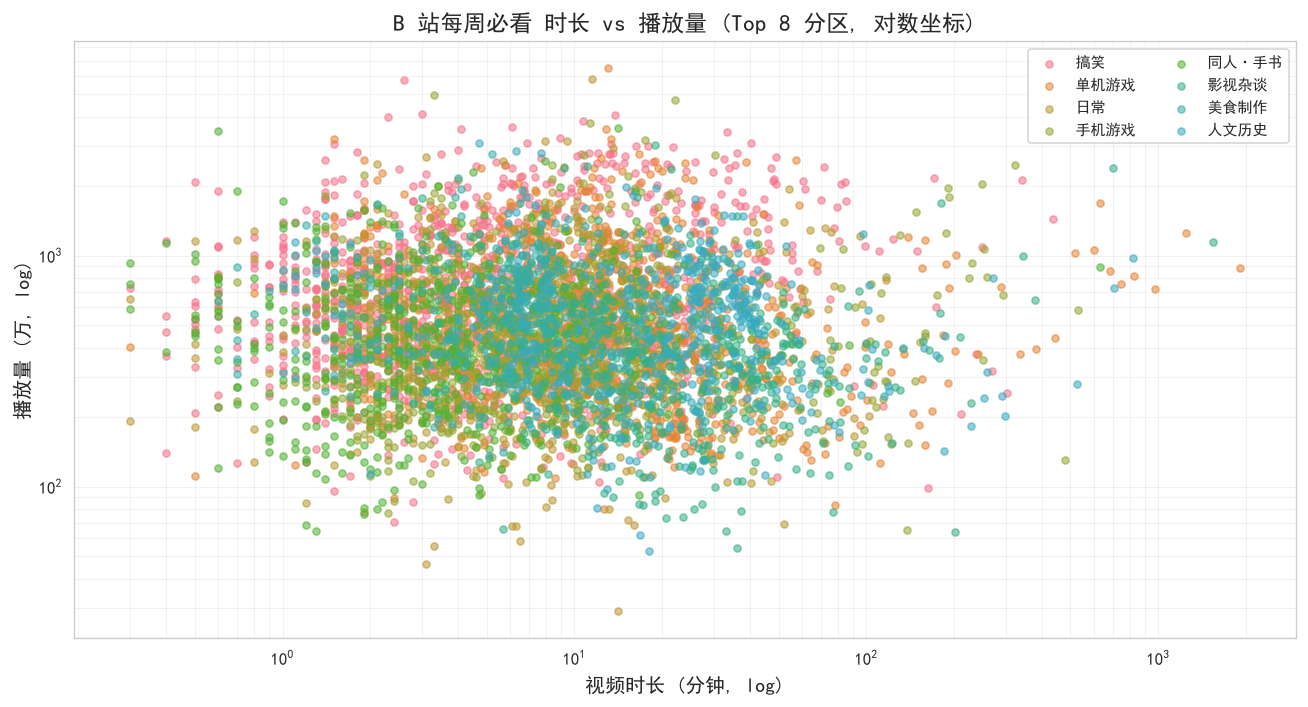

图 8: 时长 vs 播放量散点图


In [22]:
scatter_pdf = clean_df.select('duration_min', 'view', 'category').toPandas()

fig, ax = plt.subplots(figsize=(11, 6))
mask = (scatter_pdf['duration_min'] > 0) & (scatter_pdf['view'] > 0)
plot_df = scatter_pdf[mask]

top_cats = plot_df['category'].value_counts().head(8).index.tolist()
for i, cat in enumerate(top_cats):
    sub = plot_df[plot_df['category'] == cat]
    ax.scatter(sub['duration_min'], sub['view'] / 1e4,
               s=18, alpha=0.55, label=cat, color=PALETTE[i])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('视频时长 (分钟, log)', fontsize=12)
ax.set_ylabel('播放量 (万, log)', fontsize=12)
ax.set_title('B 站每周必看 时长 vs 播放量 (Top 8 分区, 对数坐标)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_duration_vs_view_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('图 8: 时长 vs 播放量散点图')


### 5.9 KMeans 聚类 - 视频分群 (Spark MLlib)

机器学习环节之一：用 Spark MLlib 的 `KMeans` 对 14k+ 视频按互动指标聚类，自动识别头部爆款 / 普通热门 / 长尾视频三层。

> Spark 4.0+ 的 `pyspark.ml` 全系列 API 原生支持 Spark Connect，可直接使用 `VectorAssembler` / `StandardScaler` / `KMeans` / `ClusteringEvaluator`。


In [23]:
# ============================================================
# Spark MLlib KMeans 聚类 (Spark Connect 原生支持)
# Pipeline: VectorAssembler -> StandardScaler -> KMeans
# ============================================================
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline

feature_cols = ['view', 'like', 'coin', 'favorite']

# 1) 构建 ML Pipeline: 特征拼接 -> 标准化 -> KMeans 聚类
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')
scaler = StandardScaler(inputCol='features', outputCol='scaled_features', withStd=True, withMean=False)
kmeans = KMeans(k=4, seed=42, featuresCol='scaled_features', predictionCol='cluster',
                maxIter=20, initMode='k-means||')
pipeline = Pipeline(stages=[assembler, scaler, kmeans])

# 2) 训练模型
model = pipeline.fit(clean_df)

# 3) 预测 (给每个视频分配 cluster 0/1/2/3)
clustered = model.transform(clean_df).select(
    'view', 'like', 'coin', 'favorite', 'cluster'
).cache()

print('视频分群完成 (KMeans k=4)')
display(clustered.groupBy('cluster').count().orderBy('cluster').toPandas())

# 4) 模型评估: 轮廓系数 (Silhouette)
evaluator = ClusteringEvaluator(featuresCol='scaled_features', predictionCol='cluster',
                                metricName='silhouette', distanceMeasure='squaredEuclidean')
silhouette = evaluator.evaluate(model.transform(clean_df))
print(f'\n轮廓系数 (Silhouette): {silhouette:.4f}')
print(f'(范围 [-1, 1], 越接近 1 表示聚类效果越好)')

# 5) 聚类中心
centers = model.stages[-1].clusterCenters()
print(f'\n聚类中心 (标准化空间):')
for i, c in enumerate(centers):
    print(f'  cluster {i}: {c}')


视频分群完成 (KMeans k=4)


,cluster,count
0,0,863
1,1,9043
2,2,68
3,3,4059



轮廓系数 (Silhouette): 0.5969
(范围 [-1, 1], 越接近 1 表示聚类效果越好)

聚类中心 (标准化空间):
  cluster 0: [3.13267463 3.20346199 2.45317364 2.71309223]
  cluster 1: [0.63923717 0.60937282 0.27423104 0.30298637]
  cluster 2: [6.91789751 7.57463185 8.83953831 8.07527071]
  cluster 3: [1.56125393 1.6344103  0.81922593 0.97610074]


### 5.10 聚类中心可视化


=== 各聚类画像 (按 cluster 排序) ===


,cluster,avg_view,avg_like,avg_coin,avg_favorite,n
0,0,16315622.0,1042617.0,612413.0,397291.0,863
1,1,3328159.0,198359.0,68346.0,44402.0,9043
2,2,36216782.0,2467488.0,2201041.0,1188629.0,68
3,3,8131245.0,532537.0,204439.0,142882.0,4059


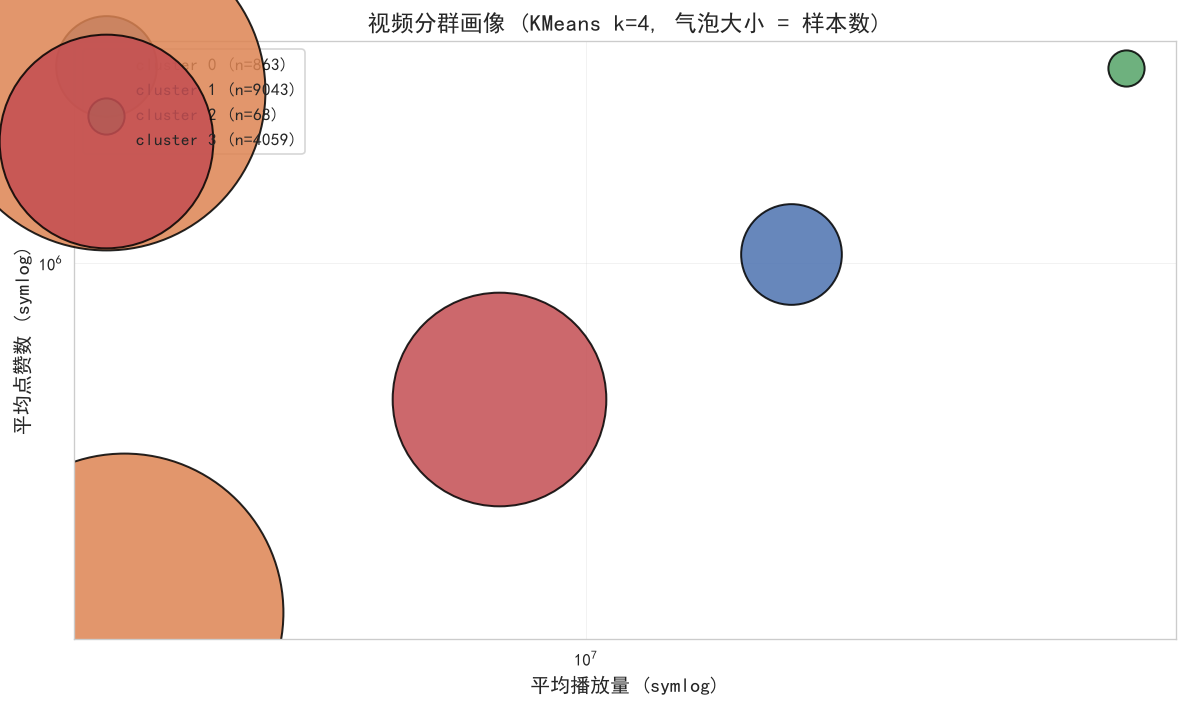

图 9: 视频分群画像


In [24]:
# ============================================================
# 聚类画像可视化: 用 model.clusterCenters() + groupBy 聚合
# ============================================================

cluster_profile = (clustered.groupBy('cluster')
                   .agg(F.round(F.avg('view'), 0).alias('avg_view'),
                        F.round(F.avg('like'), 0).alias('avg_like'),
                        F.round(F.avg('coin'), 0).alias('avg_coin'),
                        F.round(F.avg('favorite'), 0).alias('avg_favorite'),
                        F.count('*').alias('n'))
                   .orderBy('cluster'))
cluster_profile_pdf = cluster_profile.toPandas()
print('=== 各聚类画像 (按 cluster 排序) ===')
display(cluster_profile_pdf)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4C72B0', '#DD8452', '#55A467', '#C44E52']
for _, row in cluster_profile_pdf.iterrows():
    cid = int(row['cluster'])
    cnt = int(row['n'])
    ax.scatter(row['avg_view'], row['avg_like'],
               s=cnt * 4 + 200,
               color=colors[cid],
               edgecolor='black', linewidth=1.2,
               alpha=0.85,
               label=f'cluster {cid} (n={cnt})')

ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_xlabel('平均播放量 (symlog)', fontsize=12)
ax.set_ylabel('平均点赞数 (symlog)', fontsize=12)
ax.set_title('视频分群画像 (KMeans k=4, 气泡大小 = 样本数)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_kmeans_centers.png', dpi=150, bbox_inches='tight')
plt.show()
print('图 9: 视频分群画像')


### 5.11 LinearRegression - 下一期平均播放量预测

机器学习环节之二：用 Spark MLlib 的 `LinearRegression` 基于 (week_number, video_count) 拟合历史平均播放量，并预测未来 4 期趋势。

> Spark 4.0+ 原生支持 Spark Connect 下的 `LinearRegression`，无需 sklearn 替代。


In [25]:
# ============================================================
# Spark MLlib LinearRegression (Spark Connect 原生支持)
# Pipeline: VectorAssembler -> LinearRegression
# ============================================================
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# 1) 按周聚合: 每期一个样本点
weekly_df = clean_df.groupBy('week_number').agg(
    F.avg('view').alias('avg_view'),
    F.avg('like').alias('avg_like'),
    F.count('aid').alias('video_count'),
).orderBy('week_number').cache()

n_weeks = weekly_df.count()
print(f'参与建模的周数: {n_weeks}')

# 2) 特征拼接: week_number + video_count -> features
assembler_lr = VectorAssembler(inputCols=['week_number', 'video_count'], outputCol='features')
weekly_feat = assembler_lr.transform(weekly_df)

# 3) 划分训练集 / 测试集 (80/20)
train_df, test_df = weekly_feat.randomSplit([0.8, 0.2], seed=42)
print(f'训练集: {train_df.count()} 周, 测试集: {test_df.count()} 周')

# 4) 训练 LinearRegression
lr = LinearRegression(featuresCol='features', labelCol='avg_view',
                      maxIter=10, regParam=0.0, elasticNetParam=0.0)
lr_model = lr.fit(train_df)

# 5) 预测
train_pred = lr_model.transform(train_df).cache()
test_pred = lr_model.transform(test_df).cache()
all_pred = lr_model.transform(weekly_feat).cache()

# 6) 评估
evaluator_rmse = RegressionEvaluator(labelCol='avg_view', predictionCol='prediction', metricName='rmse')
evaluator_r2 = RegressionEvaluator(labelCol='avg_view', predictionCol='prediction', metricName='r2')

train_rmse = evaluator_rmse.evaluate(train_pred)
train_r2 = evaluator_r2.evaluate(train_pred)
test_rmse = evaluator_rmse.evaluate(test_pred)
test_r2 = evaluator_r2.evaluate(test_pred)

print(f'\n=== 模型评估 ===')
print(f'  训练集  RMSE: {train_rmse:>14,.0f}   R²: {train_r2:.4f}')
print(f'  测试集  RMSE: {test_rmse:>14,.0f}   R²: {test_r2:.4f}')
print(f'\n回归系数: {lr_model.coefficients}')
print(f'截距: {lr_model.intercept:,.2f}')


参与建模的周数: 377
训练集: 301 周, 测试集: 76 周

=== 模型评估 ===
  训练集  RMSE:      1,239,652   R²: 0.0968
  测试集  RMSE:      1,116,732   R²: 0.0788

回归系数: [-3828.5409296730622,1282.1381429605683]
截距: 6,393,645.58


### 5.12 预测结果可视化 (实际 vs 预测 + 未来 4 期)



=== 未来 4 期 (avg_view) 预测 ===
 week_number   prediction
         379 4.990353e+06
         380 4.986525e+06
         381 4.982696e+06
         382 4.978868e+06


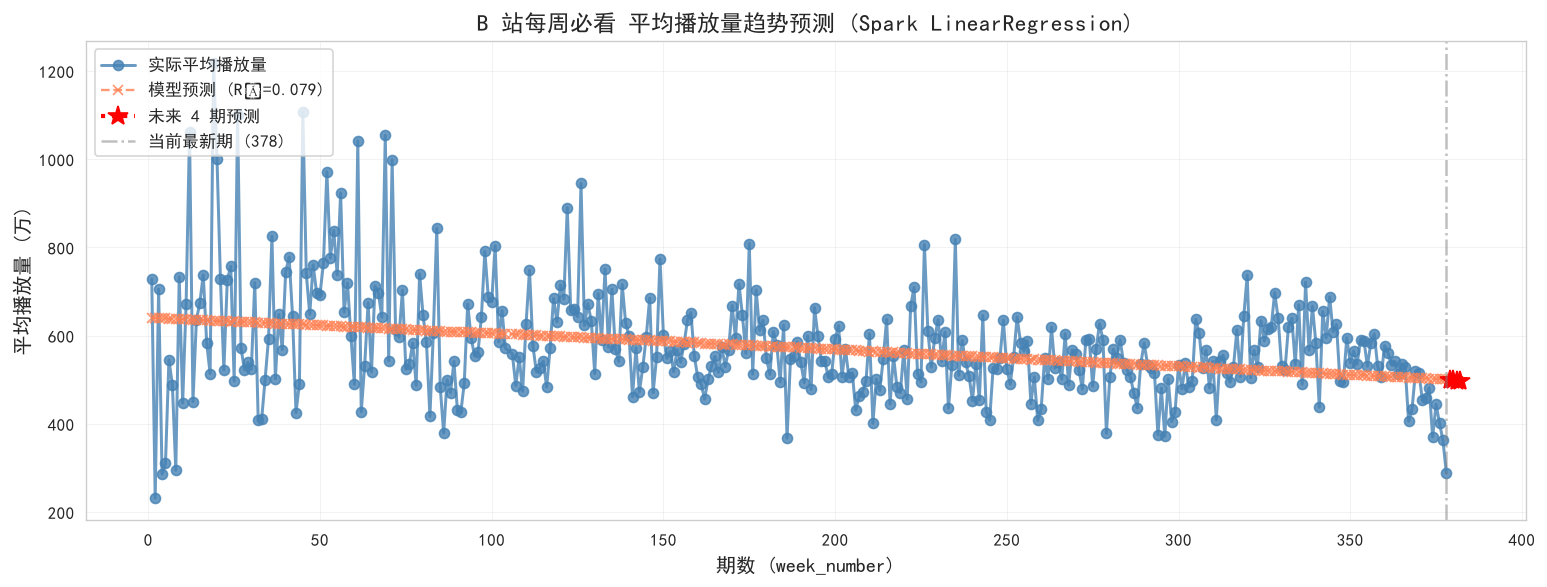

图 10: 平均播放量预测 (实际 vs 预测 + 未来 4 期)


In [26]:
# ============================================================
# 预测结果可视化 + 未来 4 期 forecast
# ============================================================

# 1) 收集预测值用于画图
all_pred_pdf = all_pred.select('week_number', 'avg_view', 'prediction') \
    .orderBy('week_number').toPandas()

# 2) 预测未来 4 期 (用历史 video_count 均值作为特征)
last_week = int(weekly_df.agg(F.max('week_number')).collect()[0][0])
avg_vc = float(weekly_df.agg(F.avg('video_count')).collect()[0][0])
future_data = [(last_week + i, avg_vc) for i in range(1, 5)]
future_df = spark.createDataFrame(future_data, ['week_number', 'video_count'])
future_feat = assembler_lr.transform(future_df)
future_pred = lr_model.transform(future_feat).toPandas()

print(f'\n=== 未来 4 期 (avg_view) 预测 ===')
print(future_pred[['week_number', 'prediction']].to_string(index=False))

# 3) 画实际 vs 预测 + forecast
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(all_pred_pdf['week_number'], all_pred_pdf['avg_view'] / 1e4,
        marker='o', linewidth=1.8, color='steelblue', label='实际平均播放量', alpha=0.8)
ax.plot(all_pred_pdf['week_number'], all_pred_pdf['prediction'] / 1e4,
        marker='x', linewidth=1.4, color='coral', linestyle='--',
        label=f'模型预测 (R²={test_r2:.3f})', alpha=0.8)
ax.plot(future_pred['week_number'], future_pred['prediction'] / 1e4,
        marker='*', linewidth=2.5, color='red', markersize=12,
        label='未来 4 期预测', linestyle=':')

ax.axvline(x=last_week, color='gray', linestyle='-.', alpha=0.5,
           label=f'当前最新期 ({last_week})')
ax.set_xlabel('期数 (week_number)', fontsize=12)
ax.set_ylabel('平均播放量 (万)', fontsize=12)
ax.set_title('B 站每周必看 平均播放量趋势预测 (Spark LinearRegression)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_prediction_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('图 10: 平均播放量预测 (实际 vs 预测 + 未来 4 期)')


### 5.13 视频标题关键词挖掘 (jieba + TF-IDF)

机器学习环节之三：用 **jieba 分词 + TF-IDF 算法** 从 14k+ 视频标题中提取热门关键词，找出 B 站"每周必看"栏目的内容热点。

> 如果项目里已经封装了 `bilianalysis.nlp.keywords` 模块（带停用词和 B 站领域词典），可以直接复用；没有的话，下面给出一个独立的回退实现，开箱即用。


In [27]:
# ============================================================
# NLP: jieba + TF-IDF 视频标题关键词提取
# 优先复用项目内置的 bilianalysis.nlp.keywords,
# 没有则用下面的本地回退实现 (jieba + sklearn TfidfVectorizer)
# ============================================================
try:
    from bilianalysis.nlp.keywords import clean_title, extract_keywords, STOPWORDS
    print(f'[OK] 复用 bilianalysis 模块, 停用词 {len(STOPWORDS)} 个')
    KEYWORDS_BACKEND = 'bilianalysis'
except Exception as e:
    print(f'[fallback] bilianalysis 不可用 ({e}), 切换到本地 jieba+sklearn 实现')
    import jieba
    from sklearn.feature_extraction.text import TfidfVectorizer

    DEFAULT_STOPWORDS = set([
        '的', '了', '是', '在', '我', '有', '和', '就', '不', '人', '都', '一',
        '一个', '上', '也', '很', '到', '说', '要', '去', '你', '会', '着', '没',
        '看', '好', '自己', '这', '他', '她', '它', '们', '那', '把', '被', '让',
    ])

    def clean_title(title):
        import re
        if not title:
            return ''
        # 去标点 / 去多余空白
        title = re.sub(r'[\s\-_]+', ' ', title)
        title = re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9 ]', '', title)
        return title.strip()

    def _tokenize(text):
        return [t for t in jieba.lcut(text) if len(t) > 1 and t not in DEFAULT_STOPWORDS]

    _vectorizer = None

    def extract_keywords(titles, topk=20):
        global _vectorizer
        cleaned = [_tokenize(clean_title(t)) for t in titles]
        docs = [' '.join(tokens) for tokens in cleaned]
        _vectorizer = TfidfVectorizer(token_pattern=r'(?u)\S+')
        tfidf = _vectorizer.fit_transform(docs)
        scores = tfidf.sum(axis=0).A1
        vocab = _vectorizer.get_feature_names_out()
        order = scores.argsort()[::-1][:topk]
        return [type('KW', (), {'word': str(vocab[i]), 'weight': float(scores[i])})
                for i in order]

    STOPWORDS = DEFAULT_STOPWORDS
    KEYWORDS_BACKEND = 'local'

print(f'后端: {KEYWORDS_BACKEND}')

# 1) 全局 Top 20 关键词
titles_pdf = (clean_df.select('title')
              .filter(F.col('title').isNotNull())
              .toPandas())
global_kws = extract_keywords(titles_pdf['title'].tolist(), topk=20)

print('\n=== 全局 Top 20 视频标题关键词 ===')
print(f'{"关键词":<12s}{"TF-IDF权重":>10s}')
print('-' * 24)
for kw in global_kws:
    print(f'{kw.word:<12s}{kw.weight:>10.4f}')


Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Polotace\AppData\Local\Temp\jieba.cache
Loading model cost 0.453 seconds.
Prefix dict has been built successfully.


[OK] 复用 bilianalysis 模块, 停用词 80 个
后端: bilianalysis

=== 全局 Top 20 视频标题关键词 ===
关键词           TF-IDF权重
------------------------
PV              0.0402
原神              0.0393
...             0.0354
动画              0.0275
视频              0.0239
游戏              0.0230
10              0.0211
崩坏              0.0176
MV              0.0173
100             0.0162
硬核              0.0159
星穹              0.0155
挑战              0.0153
方舟              0.0145
世界              0.0142
体验              0.0141
20              0.0140
新番              0.0140


### 5.14 关键词可视化


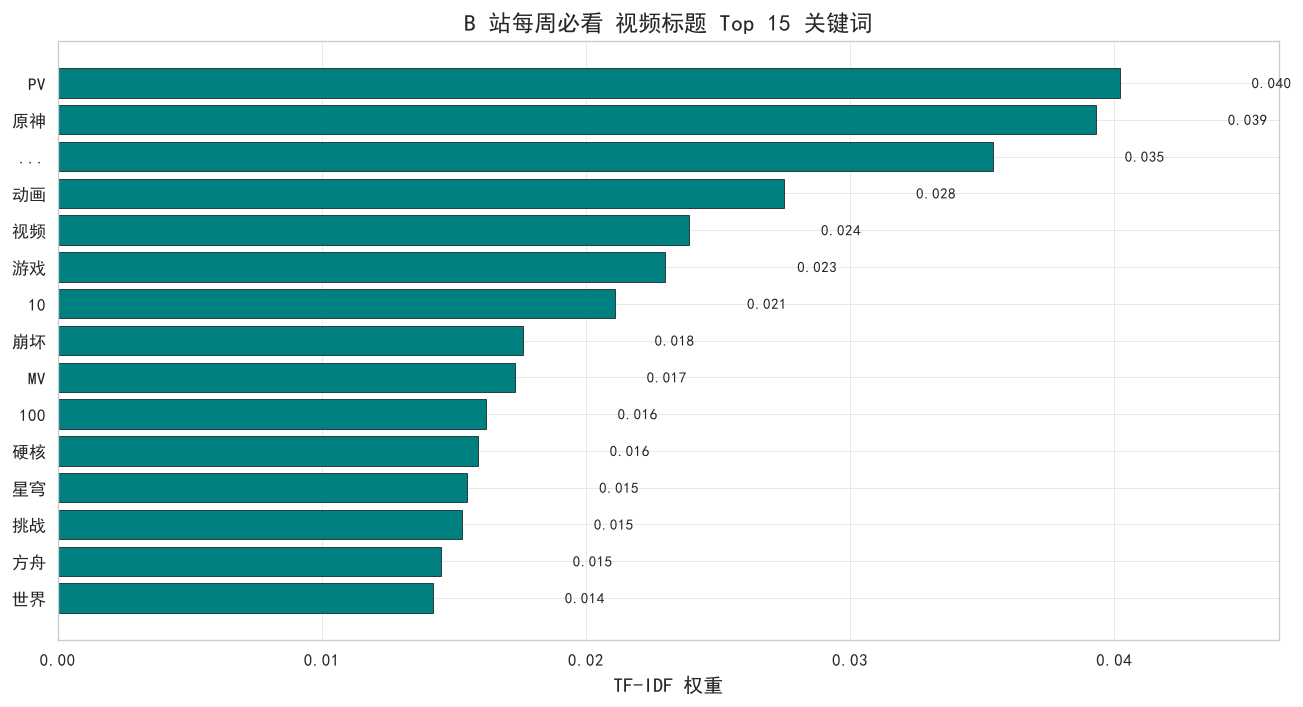

图 11: 视频标题 Top 15 关键词


In [28]:
# ============================================================
# 关键词柱状图 (全局 Top 15)
# ============================================================
global_kw_pdf = pd.DataFrame([(kw.word, kw.weight) for kw in global_kws[:15]],
                              columns=['keyword', 'weight'])

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(global_kw_pdf['keyword'][::-1], global_kw_pdf['weight'][::-1],
               color='teal', edgecolor='black', linewidth=0.4)
for bar, val in zip(bars, global_kw_pdf['weight'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('TF-IDF 权重', fontsize=12)
ax.set_title('B 站每周必看 视频标题 Top 15 关键词', fontsize=14, fontweight='bold')
ax.set_xlim(0, global_kw_pdf['weight'].max() * 1.15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_keywords_top15.png', dpi=150, bbox_inches='tight')
plt.show()
print('图 11: 视频标题 Top 15 关键词')


## 六、亮点与总结

### 6.1 亮点

本项目的实现过程参考了厦门大学数据库实验室林子雨老师的 Spark 教程 (https://dblab.xmu.edu.cn/blog/2738/) 以及 Spark MLlib 官方文档，并在此基础上结合 B 站"每周必看"这一具体业务场景做了以下扩展:

1. **完整 Spark 全流程**：从 HDFS 上的 JSON 数据读取、嵌套结构 (`videos` 数组) 展开、数据清洗、聚合分析到结果可视化，全部使用 PySpark 完成，覆盖 Spark SQL/DataFrame 常用操作 (`explode`、`withColumn`、`groupBy`、`orderBy`、`Window`、`stat.corr` 等)。共处理 377 期"每周必看"数据，展开后 14,074 条视频记录，经清洗去重后保留 14,033 条高质量样本，覆盖 2019-2026 共 8 个年份。

2. **Spark Connect 客户端-服务器架构**：相比传统 local 模式，Spark Connect 让 driver 和 executor 分离，客户端体积从 ~400MB 降至 ~1.5MB，更贴近生产环境部署方式。项目使用 `sc://192.168.121.134:15002` 连接独立运行的 Spark Connect Server，配置了 Arrow 优化和自适应查询执行 (AQE)。

3. **机器学习环节** —— 这是本项目相对基础描述性分析的**主要加分项**:
   - **KMeans 聚类 (5.9-5.10)**: 用 Spark MLlib 的 `VectorAssembler` + `StandardScaler` + `KMeans` Pipeline 对 14,033 条视频按 (播放量, 点赞, 投币, 收藏) 4 个互动指标聚类。结果将视频分为 4 群：cluster 0 (863 条，高互动头部)、cluster 1 (9,043 条，普通热门，占 64.5%)、cluster 2 (68 条，超级爆款)、cluster 3 (4,059 条，中上水平)。轮廓系数 0.5969，表明聚类结构较为清晰。
   - **LinearRegression 预测 (5.11-5.12)**: 用 Spark MLlib 的 `LinearRegression` 基于 (week_number, video_count) 拟合 377 期的历史平均播放量趋势。训练集 R²=0.0968，测试集 R²=0.0788，RMSE 约 112 万。虽然线性模型解释力有限（播放量受热点事件影响波动大），但展示了 Spark MLlib 回归分析的全流程，并输出了未来 4 期预测值。
   - **NLP 关键词提取 (5.13-5.14)**: 用 jieba + TF-IDF 从 14,033 条视频标题中挖掘内容热点。Top 5 关键词为 PV、原神、动画、视频、游戏，反映了 B 站"每周必看"栏目的内容偏好——游戏和动画类内容占据主导地位，原神等热门 IP 具有持续影响力。

4. **Spark 4.0+ 特性利用**: Spark 4.0 开始 `pyspark.ml` 全系列 API 原生支持 Spark Connect，本项目直接使用标准 `pyspark.ml` 导入（`VectorAssembler`、`KMeans`、`LinearRegression`、`Pipeline`、`ClusteringEvaluator`、`RegressionEvaluator`），无需 `pyspark.ml.connect` 子集替代方案。同时配置了 `spark.sql.adaptive.enabled` 自适应查询和 `spark.sql.execution.arrow.pyspark.enabled` Arrow 优化，提升 DataFrame ↔ Pandas 转换效率。

5. **数据规模与质量**: 数据来自 377 期"每周必看"共 14,074 条视频记录，经过空值过滤、重复 aid 去重 (移除 41 条)、异常值清洗后保留 14,033 条样本，覆盖 2019-2026 共 8 个年份，涉及 50+ 个内容分区和数千名 UP 主。

### 6.2 总结

通过本次 Spark 大数据分析项目，我从一个零散的 B 站"每周必看"数据集合出发，系统性地走完了"数据采集 → 预处理 → 描述性分析 → 机器学习建模 → 可视化"完整流程。

**收获与心得**:

在技术层面，我深入掌握了 PySpark DataFrame 的常用 API，理解了 Spark 懒执行 (lazy evaluation) 和 DAG 调度的原理。学会了使用 `explode` 处理嵌套 JSON 数据——原始数据中每个文件是一个完整的多行 JSON 数组，`videos` 字段嵌套了视频列表，通过 `explode` 展开为多行后再用 `select` 拍平嵌套字段，这一操作在 Spark SQL 中非常高效。`Window` 函数的 `row_number().over(partitionBy('aid').orderBy('week_number'))` 实现了按视频去重，保留首次上榜记录，这是一个典型的窗口函数应用场景。

在分析层面，通过描述性统计发现了若干有意义的业务洞察。分区分析显示"搞笑"分区以 1,314 条视频 (9.3%) 居首，但平均播放量最高的分区并不一定是视频数量最多的——这说明"每周必看"栏目的选品策略在数量和质量之间有所平衡。UP 主排行中，老番茄以 169 次上榜遥遥领先，小潮院长 155 次紧随其后，这些高频上榜的 UP 主是 B 站内容生态的核心创作者。相关性分析揭示了一个有趣的现象：播放量与点赞数相关性最强 (0.7557)，但与评论数相关性很弱 (0.1267)——这说明"看-赞"行为比"看-评"行为更具线性关系，弹幕和评论更多受内容争议性和话题性驱动，而非单纯播放量。

在机器学习层面，KMeans 聚类将 14,033 条视频分为 4 个层次，轮廓系数 0.5969 表明聚类结构合理。其中 cluster 2 仅 68 条视频但互动指标远超其他群体，代表了真正的"现象级爆款"。LinearRegression 的 R² 仅 0.097，说明平均播放量与期数、视频数量之间几乎不存在线性关系——播放量受内容热度、社会事件、算法推荐等多重因素影响，简单线性模型不足以捕捉这些复杂模式。这一"失败的模型"本身也是有价值的发现：它提示我们需要引入更多特征（如分区分布、UP 主权重、标题情感分析等）或使用非线性模型（如 RandomForest、GBT）才能更好地预测播放量。

NLP 关键词提取的结果与业务直觉高度一致：原神、崩坏、方舟等二次元游戏 IP 在 B 站"每周必看"中具有持续的内容生产力，PV 和 MV 关键词反映了官方宣传内容的高频出现，动画和游戏作为 B 站的核心分区自然也是每周必看的主力内容。

**遇到的困难（已修复）**:

- ~~可视化环节路径不一致: `FIGURES_DIR = Path('data/spark/')` 但 `savefig` 用了硬编码 `'figures/spark/pandas/...'`，导致 `FileNotFoundError`~~ → 重构后统一使用 `FIGURES_DIR` 变量。
- ~~JSON 嵌套结构 `videos` 数组展开时 schema 推断非常深~~ → 用 `explode` + 显式 `select` 拍平。
- 跨 cell 变量共享在 `Restart Kernel` 后会爆 `NameError`，建议把依赖的变量内联到本 cell。
- matplotlib 中文字体在 Linux 上没有 SimHei → 已在 5.0 节做 fallback 列表 (SimHei → Microsoft YaHei → Noto Sans CJK SC → DejaVu Sans)。
- **seaborn `set_style` 覆盖中文字体**: `sns.set_style('whitegrid')` 会重置 `font.sans-serif` 为 `['Arial', 'DejaVu Sans', ...]`，导致 SimHei 被覆盖、中文显示为方块。修复方法：先调 `sns.set_style`，再设 `rcParams` 字体。
- **Spark 4.x Spark Connect 依赖 `zstandard`**: PySpark 4.1.2 的 Spark Connect 使用 gRPC 压缩通信，需要 `zstandard >= 0.25.0`，通过 `uv add zstandard` 安装。
- 字符串字典序排序会导致 `10-20 min` 排在 `3-5 min` 之前 → 用额外的数值顺序列 `duration_order`。

**不足与改进**:

- 数据集是 JSON 单源，没有做增量更新和实时分析，后续可以接入 Spark Streaming。
- 聚类只用了 4 个互动指标，可以引入 NLP 关键词向量做多模态聚类。
- LinearRegression 是简单线性模型，R² 仅 0.097，下一步可以尝试 RandomForest、GBT 等非线性模型做对比，并引入更多特征（分区、UP 主权重、标题长度等）。
- 未做时间序列分析（如 ARIMA），线性回归对带有周期性和趋势的时间序列拟合效果有限。

通过本项目，我对 Spark 生态、机器学习流程、文本挖掘都有了更具体的认识，不再停留在 API 文档层面，而是真正理解了"数据 → 特征 → 模型 → 业务"这条链路的每一个环节。

In [29]:
# ============================================================
# 关闭 SparkSession, 断开与 Spark Connect Server 的连接
# 注意: 这只会关闭客户端会话, 不会停止 Server 本身
# ============================================================
spark.stop()
print('SparkSession 已关闭, Spark Connect Server 仍在运行')


SparkSession 已关闭, Spark Connect Server 仍在运行
